# Sprint 4.2 - Configuring TLS Data to include CBH & CR

In [43]:
# ------------------------
# IMPORTS
# ------------------------

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

In [81]:
# ------------------------
# SETUP & DATA LOADING
# ------------------------

# Load tree data
ff_data = pd.read_csv("./data/FF_treelist_all.csv")
plot_id = pd.read_csv("./data/01_plot_identification.csv")
tls_data = pd.read_csv("./data/TLS_treelist.csv")
ref_species = pd.read_csv("./data/REF_SPECIES.csv")
pft_codes = pd.read_csv("./data/FIATreeSpeciesCode_pft.csv")

In [82]:
# ------------------------
# DATA CLEANING & MERGING
# ------------------------

ff_data = ff_data.dropna()
ff_data["site_name"] = ff_data["site_name"].astype("category")
ff_data["site_name_cat"] = ff_data["site_name"].cat.codes

plot_id["plot_blk"] = plot_id["plot_blk"].str.replace(".ptx", "", regex=False).str.strip()

tls_data["DIA"] = tls_data["DBH"] * 2.54
enhanced_tls = tls_data.merge(plot_id[['plot_blk', 'site_name']], on="plot_blk", how="left")
enhanced_tls["site_name"] = enhanced_tls["site_name"].astype("category")
enhanced_tls["site_name_cat"] = enhanced_tls["site_name"].cat.codes
enhanced_tls.head()

,Unnamed: 0,TreeID,X,Y,Radius,Error,H,h_radius,DBH,BasalA,plot_blk,DIA,site_name,site_name_cat
0,0,1,10.673382,2.127033,0.266540,0.001199,12.560,1.3,20.987379,2.402324,CAFKU_0101_20240802_1,53.307943,SHA,1
1,3,6,2.429448,1.055521,0.166444,0.000730,8.742,1.3,13.105771,0.936786,CAFKU_0101_20240802_1,33.288659,SHA,1
2,4,8,2.149436,0.950025,0.759981,0.001151,13.469,1.3,59.840890,19.530404,CAFKU_0101_20240802_1,151.995860,SHA,1
3,5,9,1.962382,8.781092,0.267219,0.001217,18.144,1.3,21.040854,2.414582,CAFKU_0101_20240802_1,53.443770,SHA,1
4,6,12,1.433234,0.234223,0.208154,0.000543,13.790,1.3,16.390056,1.465130,CAFKU_0101_20240802_1,41.630742,SHA,1


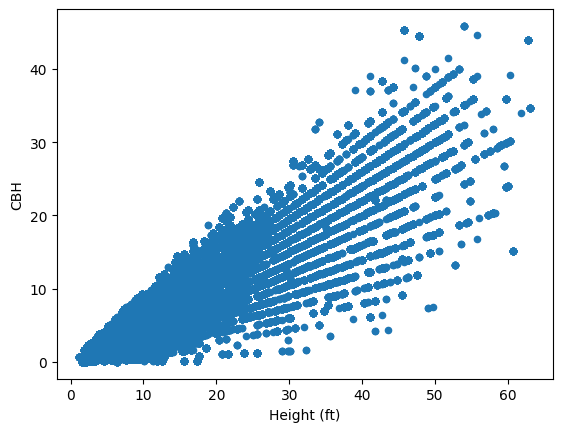

In [68]:
# ------------------------
# DISCOVERING RELATIONSHIPS TO PREDICT CR & CBH FOR TLS DATA
# ------------------------

fig, ax = plt.subplots()
ff_data.plot.scatter(x="HT", y="CBH", ax=ax)
ax.set_xlabel("Height (ft)")
ax.set_ylabel("CBH")
plt.show()

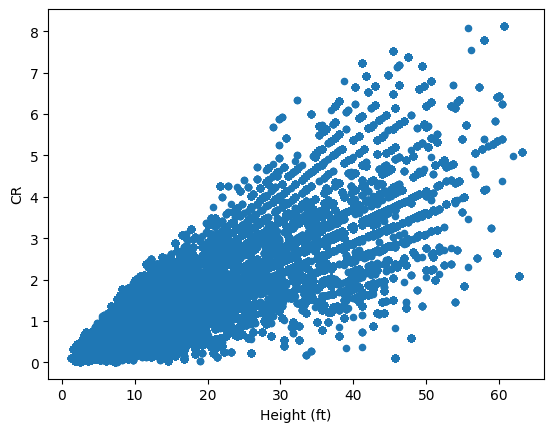

In [69]:
fig, ax = plt.subplots()
ff_data.plot.scatter(x="HT", y="CR", ax=ax)
ax.set_xlabel("Height (ft)")
ax.set_ylabel("CR")
plt.show()


=== CBH MODEL PERFORMANCE ===
R² Score: 0.837
RMSE: 9.739

=== CR MODEL PERFORMANCE ===
R² Score: 0.698
RMSE: 0.433


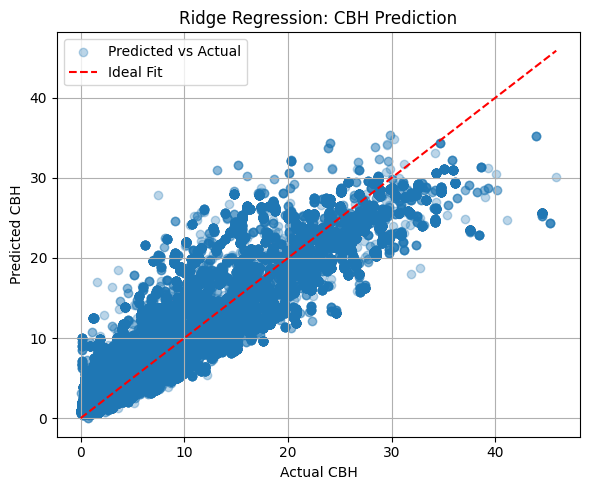

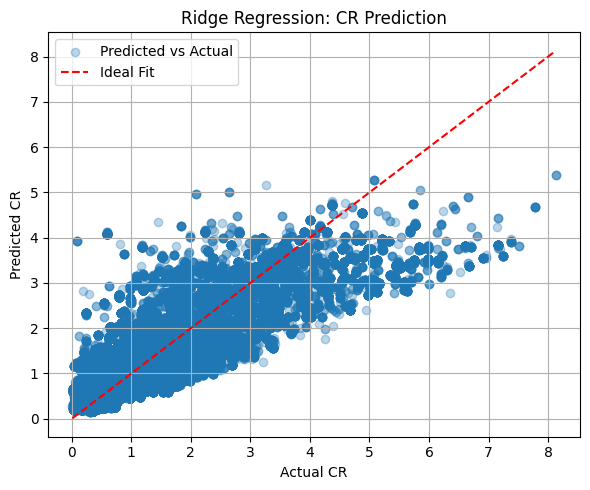

In [70]:
# ------------------------
# RIDGE REGRESSION TO PREDICT CBH & CR FOR FASTFUELS -- V1
# ------------------------

# Features and targets
X = ff_data[["HT", "DIA", "site_name_cat"]].copy()
y_cbh = ff_data["CBH"]
y_cr = ff_data["CR"]

# Train/test split
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X, y_cbh, test_size=0.2, random_state=42)
X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(X, y_cr, test_size=0.2, random_state=42)

# Ridge models
cbh_model = Ridge(alpha=1.0)
cr_model = Ridge(alpha=1.0)

# Fit
cbh_model.fit(X_train_cb, y_train_cb)
cr_model.fit(X_train_cr, y_train_cr)

# Predict
y_pred_cb = cbh_model.predict(X_test_cb)
y_pred_cr = cr_model.predict(X_test_cr)

print("\n=== CBH MODEL PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test_cb, y_pred_cb):.3f}")
print(f"RMSE: {mean_squared_error(y_test_cb, y_pred_cb):.3f}")

print("\n=== CR MODEL PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test_cr, y_pred_cr):.3f}")
print(f"RMSE: {mean_squared_error(y_test_cr, y_pred_cr):.3f}")


# ------------------------
# PLOTTING RIDGE REGRESSION RESULTS
# ------------------------

# Plot CBH Predictions
plt.figure(figsize=(6, 5))
plt.scatter(y_test_cb, y_pred_cb, alpha=0.3, label="Predicted vs Actual")
plt.plot([y_test_cb.min(), y_test_cb.max()], [y_test_cb.min(), y_test_cb.max()], 'r--', label="Ideal Fit")
plt.xlabel("Actual CBH")
plt.ylabel("Predicted CBH")
plt.title("Ridge Regression: CBH Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot CR Predictions
plt.figure(figsize=(6, 5))
plt.scatter(y_test_cr, y_pred_cr, alpha=0.3, label="Predicted vs Actual")
plt.plot([y_test_cr.min(), y_test_cr.max()], [y_test_cr.min(), y_test_cr.max()], 'r--', label="Ideal Fit")
plt.xlabel("Actual CR")
plt.ylabel("Predicted CR")
plt.title("Ridge Regression: CR Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Using Ridge Regression instead of just Linear Regression to avoid overfitting. However, this model is not very good for predicting CR (R^2 ~ 0.7) whereas it does a great job for CBH (R^2 ~ 0.84). To try to get a higher R^2, especially for CR, we will try random forest regression.


=== CR MODEL (Random Forest) PERFORMANCE ===
R² Score: 0.993
RMSE: 0.011

=== CBH MODEL (Random Forest) PERFORMANCE ===
R² Score: 0.995
RMSE: 0.293


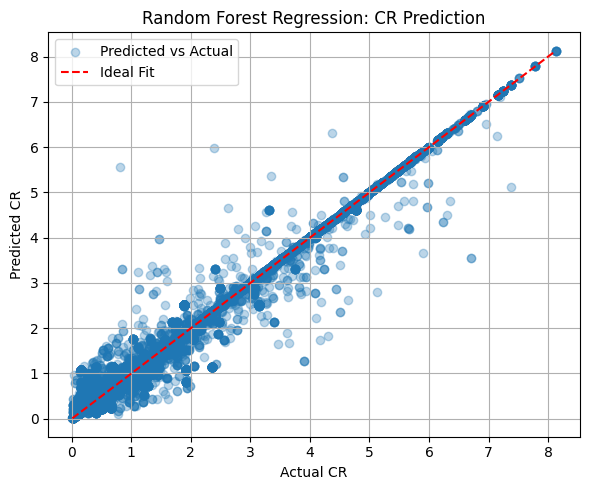

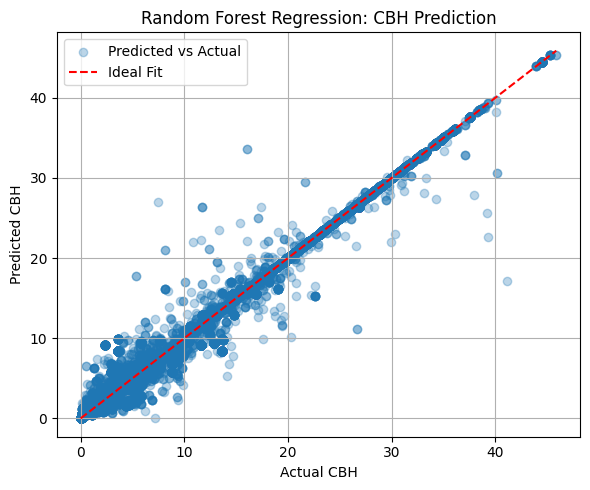

In [71]:
# ------------------------
# RANDOM FOREST REGRESSION TO PREDICT CBH & CR FOR FASTFUELS - V2
# ------------------------

X = ff_data[["HT", "DIA", "site_name_cat"]]
y_cr = ff_data["CR"]
y_cb = ff_data["CBH"]

X_train_cr, X_test_cr, y_train_cr, y_test_cr = train_test_split(X, y_cr, test_size=0.3, random_state=42)
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X, y_cb, test_size=0.3, random_state=42)

rf_cr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cbh_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_cr_model.fit(X_train_cr, y_train_cr)
rf_cbh_model.fit(X_train_cb, y_train_cb)

y_pred_cbh = rf_cbh_model.predict(X_test_cb)
y_pred_cr = rf_cr_model.predict(X_test_cr)

print("\n=== CR MODEL (Random Forest) PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test_cr, y_pred_cr):.3f}")
print(f"RMSE: {mean_squared_error(y_test_cr, y_pred_cr):.3f}")

print("\n=== CBH MODEL (Random Forest) PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test_cb, y_pred_cbh):.3f}")
print(f"RMSE: {mean_squared_error(y_test_cb, y_pred_cbh):.3f}")


# ------------------------
# PLOTTING RANDOM FOREST REGRESSION RESULTS
# ------------------------

# CR Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test_cr, y_pred_cr, alpha=0.3, label="Predicted vs Actual")
plt.plot([y_test_cr.min(), y_test_cr.max()], [y_test_cr.min(), y_test_cr.max()], 'r--', label="Ideal Fit")
plt.xlabel("Actual CR")
plt.ylabel("Predicted CR")
plt.title("Random Forest Regression: CR Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# CBH Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test_cb, y_pred_cbh, alpha=0.3, label="Predicted vs Actual")
plt.plot([y_test_cb.min(), y_test_cb.max()], [y_test_cb.min(), y_test_cb.max()], 'r--', label="Ideal Fit")
plt.xlabel("Actual CBH")
plt.ylabel("Predicted CBH")
plt.title("Random Forest Regression: CBH Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As we hypothesized, the Random Forest Regression model is way more accurate, with R^2 ~ 0.99 for both! However, we are aware that this sort of model is prone to over-fitting, which is a trade-off between picking this model and ridge regression. We tried combatting this by making the size of the testing set larger for this model, as 30% of the dataset rather than 20% for ridge regression, and the random forest regression model still outperformed. Now, we will train this model on the ENTIRE fastfuels dataset and then predict the CBH and CR values for the TLS dataset.

In [93]:
# ------------------------
# GETTING CBH & CR FOR TLS DATA
# ------------------------

rf_cr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cbh_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cr_model.fit(X, y_cr)
rf_cbh_model.fit(X, y_cb)

# Predict for TLS 
enhanced_tls = enhanced_tls.rename(columns={"H": "HT"})
enhanced_tls["CBH"] = rf_cbh_model.predict(enhanced_tls[["HT", "DIA", "site_name_cat"]])
enhanced_tls["CR"] = rf_cr_model.predict(enhanced_tls[["HT", "DIA", "site_name_cat"]])
enhanced_tls

,Unnamed: 0,TreeID,X,Y,Radius,Error,HT,h_radius,DBH,BasalA,plot_blk,DIA,site_name,site_name_cat,CBH,CR
0,0,1,10.673382,2.127033,0.266540,0.001199,12.560,1.3,20.987379,2.402324,CAFKU_0101_20240802_1,53.307943,SHA,1,4.364431,1.571625
1,3,6,2.429448,1.055521,0.166444,0.000730,8.742,1.3,13.105771,0.936786,CAFKU_0101_20240802_1,33.288659,SHA,1,4.032504,1.176590
2,4,8,2.149436,0.950025,0.759981,0.001151,13.469,1.3,59.840890,19.530404,CAFKU_0101_20240802_1,151.995860,SHA,1,9.582760,1.295846
3,5,9,1.962382,8.781092,0.267219,0.001217,18.144,1.3,21.040854,2.414582,CAFKU_0101_20240802_1,53.443770,SHA,1,10.513162,1.543894
4,6,12,1.433234,0.234223,0.208154,0.000543,13.790,1.3,16.390056,1.465130,CAFKU_0101_20240802_1,41.630742,SHA,1,4.217670,1.777529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,17,21,-9.820196,2.799561,0.220015,0.000291,30.631,1.3,17.323968,1.636854,CATCU_0016_20240929_1,44.002880,tcu,4,18.326862,1.942242
1378,18,22,2.043417,-9.313768,0.308002,0.000450,23.077,1.3,24.252048,3.207835,CATCU_0016_20240929_1,61.600203,tcu,4,12.907518,2.769598
1379,20,24,-8.147035,6.844047,0.226510,0.000211,30.127,1.3,17.835430,1.734931,CATCU_0016_20240929_1,45.301991,tcu,4,18.105120,2.142381
1380,21,25,-2.692303,-8.172273,0.180451,0.000266,29.300,1.3,14.208700,1.101093,CATCU_0016_20240929_1,36.090098,tcu,4,15.903550,2.691191


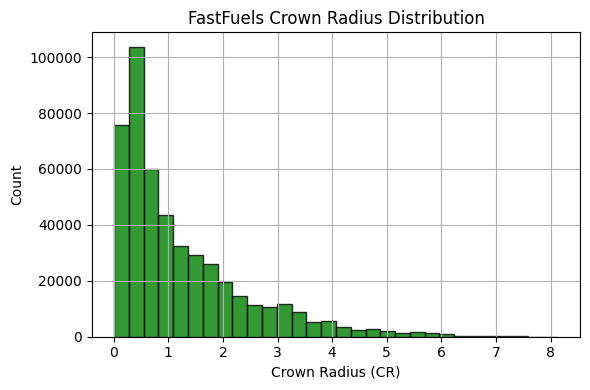

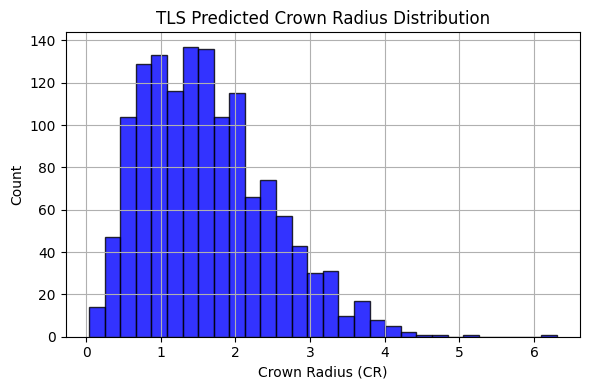

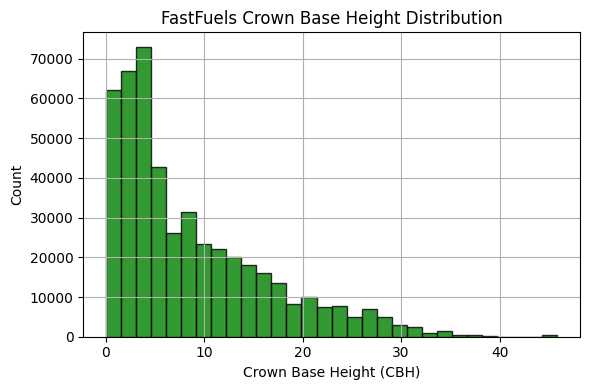

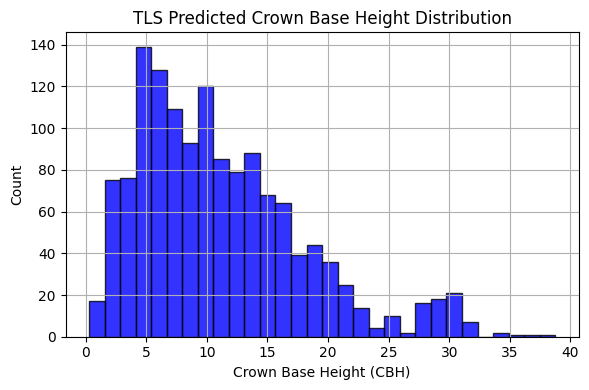

In [94]:
# ------------------------
# FastFuels CR
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(ff_data["CR"], bins=30, alpha=0.8, color="green", edgecolor='black')
plt.xlabel("Crown Radius (CR)")
plt.ylabel("Count")
plt.title("FastFuels Crown Radius Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# TLS Predicted CR
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(enhanced_tls["CR"], bins=30, alpha=0.8, color="blue", edgecolor='black')
plt.xlabel("Crown Radius (CR)")
plt.ylabel("Count")
plt.title("TLS Predicted Crown Radius Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# FastFuels CBH
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(ff_data["CBH"], bins=30, alpha=0.8, color="green", edgecolor='black')
plt.xlabel("Crown Base Height (CBH)")
plt.ylabel("Count")
plt.title("FastFuels Crown Base Height Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# TLS Predicted CBH
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(enhanced_tls["CBH"], bins=30, alpha=0.8, color="blue", edgecolor='black')
plt.xlabel("Crown Base Height (CBH)")
plt.ylabel("Count")
plt.title("TLS Predicted Crown Base Height Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
# ------------------------
# Logistic Results
# ------------------------

cbh_model = Ridge(alpha=1.0)
cr_model = Ridge(alpha=1.0)
cr_model.fit(X, y_cr)
cbh_model.fit(X, y_cb)

temp = enhanced_tls.copy()
temp["CBH"] = cbh_model.predict(temp[["HT", "DIA", "site_name_cat"]])
temp["CR"] = cr_model.predict(temp[["HT", "DIA", "site_name_cat"]])
enhanced_tls

,Unnamed: 0,TreeID,X,Y,Radius,Error,HT,h_radius,DBH,BasalA,plot_blk,DIA,site_name,site_name_cat,CBH,CR
0,0,1,10.673382,2.127033,0.266540,0.001199,12.560,1.3,20.987379,2.402324,CAFKU_0101_20240802_1,53.307943,SHA,1,4.364431,1.571625
1,3,6,2.429448,1.055521,0.166444,0.000730,8.742,1.3,13.105771,0.936786,CAFKU_0101_20240802_1,33.288659,SHA,1,4.032504,1.176590
2,4,8,2.149436,0.950025,0.759981,0.001151,13.469,1.3,59.840890,19.530404,CAFKU_0101_20240802_1,151.995860,SHA,1,9.582760,1.295846
3,5,9,1.962382,8.781092,0.267219,0.001217,18.144,1.3,21.040854,2.414582,CAFKU_0101_20240802_1,53.443770,SHA,1,10.513162,1.543894
4,6,12,1.433234,0.234223,0.208154,0.000543,13.790,1.3,16.390056,1.465130,CAFKU_0101_20240802_1,41.630742,SHA,1,4.217670,1.777529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,17,21,-9.820196,2.799561,0.220015,0.000291,30.631,1.3,17.323968,1.636854,CATCU_0016_20240929_1,44.002880,tcu,4,18.326862,1.942242
1378,18,22,2.043417,-9.313768,0.308002,0.000450,23.077,1.3,24.252048,3.207835,CATCU_0016_20240929_1,61.600203,tcu,4,12.907518,2.769598
1379,20,24,-8.147035,6.844047,0.226510,0.000211,30.127,1.3,17.835430,1.734931,CATCU_0016_20240929_1,45.301991,tcu,4,18.105120,2.142381
1380,21,25,-2.692303,-8.172273,0.180451,0.000266,29.300,1.3,14.208700,1.101093,CATCU_0016_20240929_1,36.090098,tcu,4,15.903550,2.691191


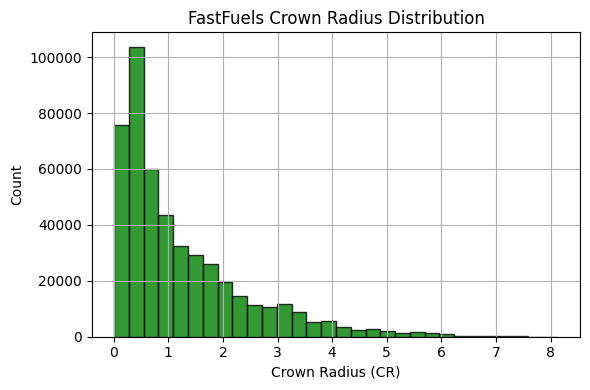

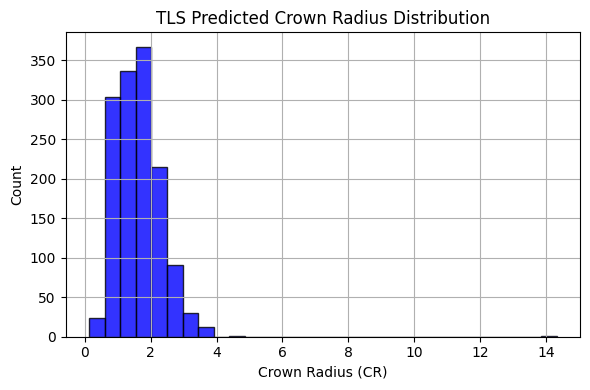

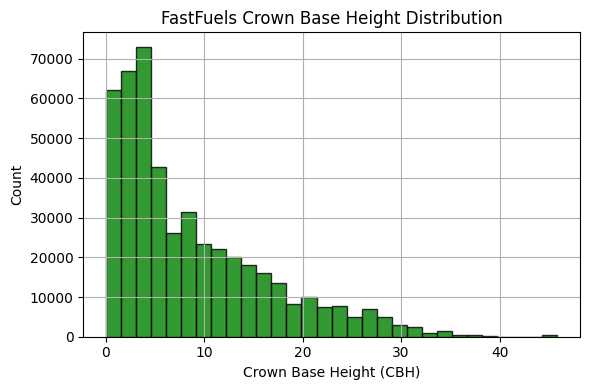

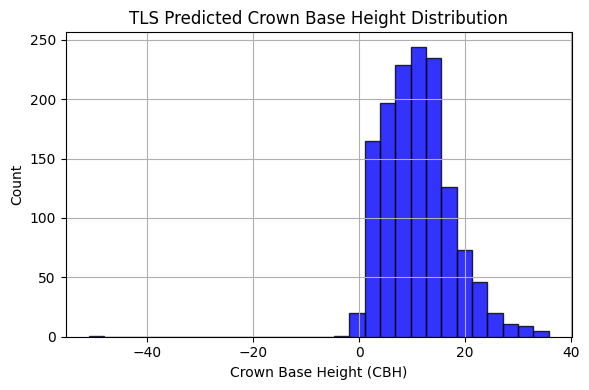

In [98]:
# ------------------------
# FastFuels CR
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(ff_data["CR"], bins=30, alpha=0.8, color="green", edgecolor='black')
plt.xlabel("Crown Radius (CR)")
plt.ylabel("Count")
plt.title("FastFuels Crown Radius Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# TLS Logistic Predicted CR
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(temp["CR"], bins=30, alpha=0.8, color="blue", edgecolor='black')
plt.xlabel("Crown Radius (CR)")
plt.ylabel("Count")
plt.title("TLS Predicted Crown Radius Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# FastFuels CBH
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(ff_data["CBH"], bins=30, alpha=0.8, color="green", edgecolor='black')
plt.xlabel("Crown Base Height (CBH)")
plt.ylabel("Count")
plt.title("FastFuels Crown Base Height Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------
# TLS Logistic Predicted CBH
# ------------------------
plt.figure(figsize=(6, 4))
plt.hist(temp["CBH"], bins=30, alpha=0.8, color="blue", edgecolor='black')
plt.xlabel("Crown Base Height (CBH)")
plt.ylabel("Count")
plt.title("TLS Predicted Crown Base Height Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

Since the Random Forest Regressor has provided us with more accurate distributions, we will use this in notebook 3.

In [100]:
# ------------------------
# SAVING TLS DATA WITH CR & CBH AS A .CSV
# ------------------------

enhanced_tls.to_csv("./data/NEW_TLS_treelist.csv", index=False)